In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_circles, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
sns.set_style("whitegrid")

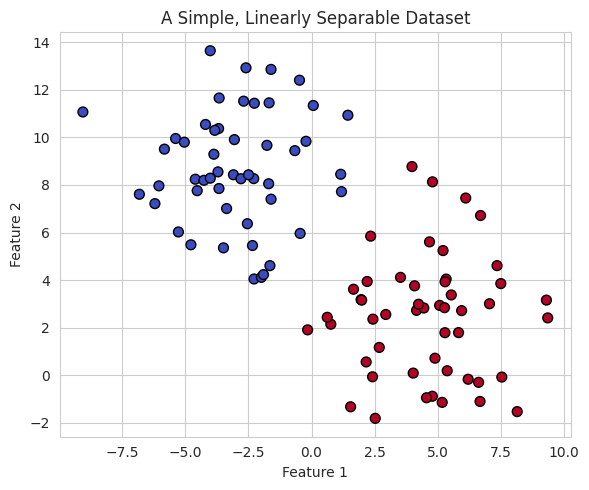

In [2]:
X, y = make_blobs(n_samples=100, centers=2, cluster_std=2.5, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=50)
plt.title("A Simple, Linearly Separable Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

In [6]:
def plot_decision_boundary(model, X, y, title, ax=None):
    """Reusable helper: plots a 2D classifier's decision regions and data points."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=40)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    return ax

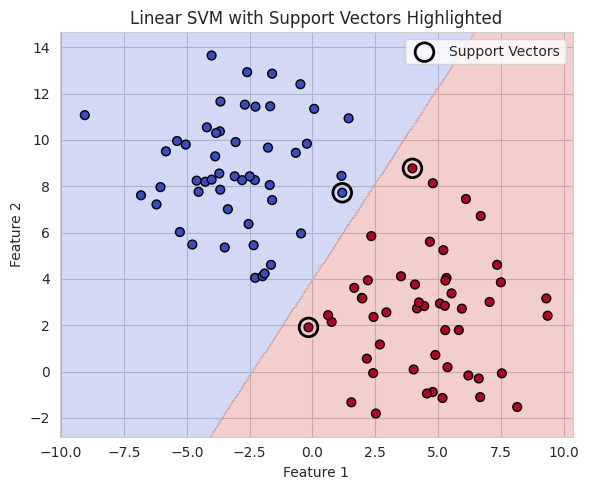

Number of support vectors: 3
Out of 100 total training points


In [7]:
svm_linear = SVC(kernel="linear", C=1000)   # very large C -> hard margin (see Hour 2)
svm_linear.fit(X, y)

ax = plot_decision_boundary(svm_linear, X, y, "Linear SVM with Support Vectors Highlighted")
ax.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1],
           s=180, facecolors="none", edgecolors="black", linewidths=2,
           label="Support Vectors")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Number of support vectors: {len(svm_linear.support_vectors_)}")
print(f"Out of {len(X)} total training points")

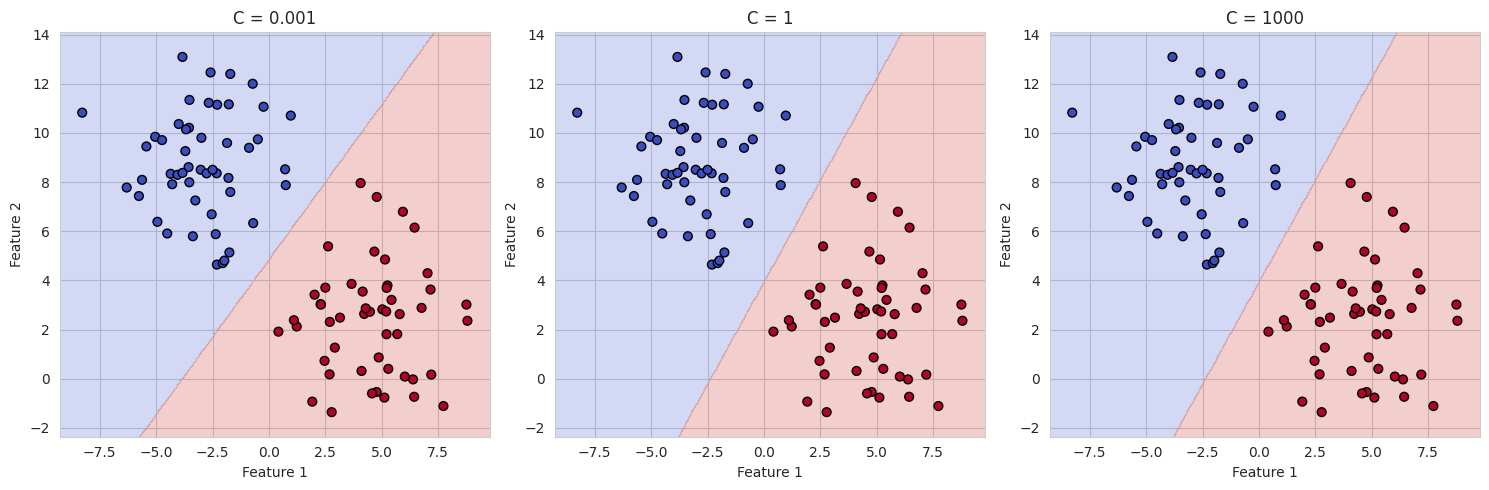

SVC(C=1000, kernel='linear')

In [8]:
X_noisy, y_noisy = make_blobs(n_samples=100, centers=2, cluster_std=2.2, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, C in zip(axes, [0.001, 1, 1000]):
    model = SVC(kernel="linear", C=C)
    model.fit(X_noisy, y_noisy)
    plot_decision_boundary(model, X_noisy, y_noisy, f"C = {C}", ax=ax)
plt.tight_layout()
plt.show()
model

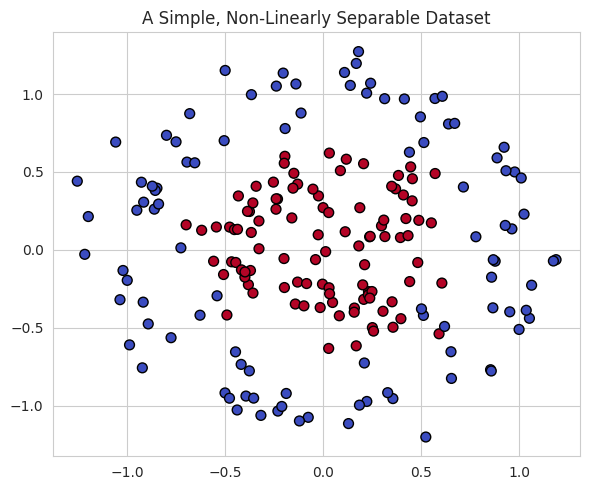

In [10]:
X_circles, y_circles = make_circles(n_samples=200, noise=0.15, factor=0.4, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap="coolwarm", edgecolors="k", s=50)
plt.title("A Simple, Non-Linearly Separable Dataset")
plt.tight_layout()
plt.show()

In [11]:
X_class, y_class = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.25, random_state=42, stratify=y_class
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # reuse TRAINING scaler, per Day 6's rule


In [12]:
param_grid = {
    "C": [0.1, 1, 10, 20, 100, 102],
    "gamma": [0.01, 0.1, 1, 0.9, 1.1, 10],
}

grid_search = GridSearchCV(
    SVC(kernel="rbf"), param_grid, cv=5, scoring="accuracy"
)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")


Best parameters: {'C': 1, 'gamma': 1}
Best cross-validation accuracy: 0.960


In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, "scale"]
}

grid_search = GridSearchCV(
    estimator=SVC(kernel="rbf"),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")
best_svm = grid_search.best_estimator_

y_pred = best_svm.predict(X_test_scaled)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Best parameters: {'C': 1, 'gamma': 0.1}
Best cross-validation accuracy: 0.983
Test accuracy: 0.967

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



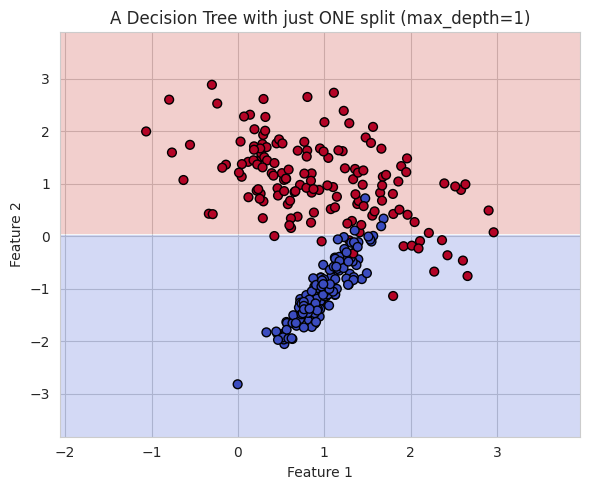

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(
    DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_class, y_class),
    X_class, y_class, "A Decision Tree with just ONE split (max_depth=1)", ax=ax
)
plt.tight_layout()
plt.show()